# TGCN: темпоральные графовые нейронные сети


Автор задач: Пасканов В.Д.

Цель семинара: изучить архитектуры Temporal Graph Conv Networks (TGCN), научиться работать с динамическими графами во временных срезах и сравнить два подхода к реализации: через `torch_geometric` и через `torch_geometric_temporal`.

Материалы:
* Zhao et al. "T-GCN: A Temporal Graph Convolutional Network for Traffic Prediction"
* Документация PyTorch Geometric Temporal:
    * https://pytorch-geometric-temporal.readthedocs.io/
    * https://pytorch-geometric-temporal.readthedocs.io/en/latest/modules/dataset.html
    * https://pytorch-geometric-temporal.readthedocs.io/en/latest/modules/signal.html
* Документация PyTorch Geometric:
    * https://pytorch-geometric.readthedocs.io/en/latest/
* Документация PyTorch:
    * https://pytorch.org/docs/stable/generated/torch.nn.GRU.html
    * https://pytorch.org/docs/stable/optim.html


In [5]:
import typing
from typing import List, Tuple, Generator, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.nn import RGCNConv
from torch_geometric_temporal.dataset import ChickenpoxDatasetLoader
from torch_geometric_temporal.signal import StaticGraphTemporalSignal, temporal_signal_split
from torch_geometric_temporal.nn.recurrent import TGCN

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Вопросы для совместного обсуждения


1. Чем темпоральные графы отличаются от статических, и почему обычного GCN/RGCN недостаточно для временных рядов на графах?

2. Как связаны понятия `snapshot`, `window` и `forecast horizon` в задаче прогнозирования на графе?

3. В чем практическая разница между реализацией через `torch_geometric` (ручной цикл по срезам) и `torch_geometric_temporal` (готовые temporal-абстракции)?


## Задачи для самостоятельного решения


<p class="task" id="1"></p>

1. Загрузите небольшой датасет из `torch_geometric_temporal` (например, `ChickenpoxDatasetLoader`).

Требования:
* сформируйте `dataset` и получите итератор временных срезов;
* выберите train/val/test разбиение по времени;
* выведите базовые статистики: число узлов, число ребер, число временных шагов, размерность признаков и целевой переменной.

- [ ] Проверено на семинаре


In [6]:
loader = ChickenpoxDatasetLoader()
dataset = loader.get_dataset()

snapshot = next(iter(dataset))

num_timesteps = sum(1 for _ in dataset)

print("=== Базовые статистики датасета Chickenpox ===")
print(f"Число узлов (Num Nodes): {snapshot.x.shape[0]}")
print(f"Число ребер (Num Edges): {snapshot.edge_index.shape[1]}")
print(f"Число временных шагов (Num Timesteps): {num_timesteps}")
print(f"Размерность признаков (Feature Dim): {snapshot.x.shape[1]}")
target_dim = snapshot.y.shape[1] if snapshot.y.dim() > 1 else 1
print(f"Размерность целевой переменной (Target Dim): {target_dim}")

=== Базовые статистики датасета Chickenpox ===
Число узлов (Num Nodes): 20
Число ребер (Num Edges): 102
Число временных шагов (Num Timesteps): 517
Размерность признаков (Feature Dim): 4
Размерность целевой переменной (Target Dim): 1


<p class="task" id="2"></p>

2. Подготовьте **два конвейера обработки одного и того же датасета**:

**Вариант A (`torch_geometric`)**
* преобразуйте каждый временной срез в объект `torch_geometric.data.Data`;
* организуйте ручной цикл по последовательности срезов;
* явно храните/передавайте скрытое состояние между шагами времени.

**Вариант B (`torch_geometric_temporal`)**
* используйте temporal-итераторы/утилиты библиотеки;
* повторите тот же протокол разбиения и предобработки.

Покажите, что оба конвейера дают согласованные входные тензоры (по размерностям и смыслу).

- [ ] Проверено на семинаре


In [ ]:
dataset_tgt = loader.get_dataset()
train_val_dataset_tgt, test_dataset_tgt = temporal_signal_split(dataset_tgt, train_ratio=0.8)
train_dataset_tgt, val_dataset_tgt = temporal_signal_split(train_val_dataset_tgt, train_ratio=0.75)


pyg_dataset: List[Data] = []
dataset_tgt = loader.get_dataset()
for time_step, snap in enumerate(dataset_tgt):
    data = Data(
        x=snap.x, 
        edge_index=snap.edge_index, 
        edge_attr=snap.edge_attr, 
        y=snap.y
    )
    pyg_dataset.append(data)

total_steps = len(pyg_dataset)
train_val_end = int(total_steps * 0.8)
train_end = int(train_val_end * 0.75)

train_dataset_pyg = pyg_dataset[:train_end]
val_dataset_pyg = pyg_dataset[train_end:train_val_end]
test_dataset_pyg = pyg_dataset[train_val_end:]

print(f"Разбиение (шагов): Train={len(train_dataset_pyg)}, Val={len(val_dataset_pyg)}, Test={len(test_dataset_pyg)}")

snap_tgt = next(iter(val_dataset_tgt))
snap_pyg = val_dataset_pyg[0]

print("\n=== Проверка согласованности конвейеров ===")
print("Форма X (TGT):", snap_tgt.x.shape, "| Форма X (PyG):", snap_pyg.x.shape)
print("Форма Y (TGT):", snap_tgt.y.shape, "| Форма Y (PyG):", snap_pyg.y.shape)

assert torch.allclose(snap_tgt.x, snap_pyg.x), "Признаки X не совпадают!"
assert torch.allclose(snap_tgt.y, snap_pyg.y), "Таргет Y не совпадает!"
print("Конвейеры идентичны по смыслу и размерностям!")

Разбиение (шагов): Train=309, Val=104, Test=104

=== Проверка согласованности конвейеров ===
Форма X (TGT): torch.Size([20, 4]) | Форма X (PyG): torch.Size([20, 4])
Форма Y (TGT): torch.Size([20]) | Форма Y (PyG): torch.Size([20])
Конвейеры идентичны по смыслу и размерностям!


<p class="task" id="3"></p>

3. Реализуйте базовую модель `TGCN` для задачи прогноза на один шаг вперед.

Требования:
* графовый блок + временной блок (GRU или эквивалент);
* общий интерфейс `forward(x_t, edge_index, h_prev) -> (y_pred, h_next)`;
* одна реализация/обертка для варианта A и одна для варианта B.

Проведите sanity-check: на одном batch/окне выведите формы `y_pred` и `h_next`.

- [ ] Проверено на семинаре


In [ ]:
class BasicTGCN(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int):
        super().__init__()
        self.tgcn = TGCN(in_channels=in_channels, out_channels=hidden_channels)
        
        self.linear = nn.Linear(hidden_channels, out_channels)

    def forward(
        self, 
        x: Tensor, 
        edge_index: Tensor, 
        edge_weight: Tensor, 
        h_prev: typing.Optional[Tensor] = None
    ) -> Tuple[Tensor, Tensor]:
        """
        Прямой проход для одного временного шага.
        
        Вход:
        - x: [Num_Nodes, In_Channels]
        - edge_index: [2, Num_Edges]
        - edge_weight: [Num_Edges]
        - h_prev: [Num_Nodes, Hidden_Channels] (Скрытое состояние с предыдущего шага)
        """
        h_next = self.tgcn(x, edge_index, edge_weight, h_prev)
        
        y_pred = self.linear(h_next)
        
        return y_pred.squeeze(-1), h_next

model = BasicTGCN(in_channels=4, hidden_channels=32, out_channels=1)

test_snap = train_dataset_pyg[0]
h_init = None

y_pred, h_next = model(test_snap.x, test_snap.edge_index, test_snap.edge_attr, h_init)

print("=== Sanity Check ===")
print(f"Ожидаемый размер y_pred: [{test_snap.num_nodes}] -> Фактический: {list(y_pred.shape)}")
print(f"Ожидаемый размер h_next: [{test_snap.num_nodes}, 32] -> Фактический: {list(h_next.shape)}")

=== Sanity Check ===
Ожидаемый размер y_pred: [20] -> Фактический: [20]
Ожидаемый размер h_next: [20, 32] -> Фактический: [20, 32]


<p class="task" id="4"></p>

4. Обучите базовый `TGCN` в обоих вариантах (`torch_geometric` и `torch_geometric_temporal`).

Требования:
* одна и та же функция потерь и метрика для обоих пайплайнов;
* одинаковое число эпох и максимально близкие гиперпараметры;
* логирование `train loss` и `val metric` каждые N эпох.

Постройте 2 графика обучения (по одному на каждый вариант) и сравните стабильность и скорость сходимости.

- [ ] Проверено на семинаре


=== Обучение Варианта A (torch_geometric) ===
Epoch 10 | Train MSE: 0.9313 | Val MSE: 0.8081
Epoch 20 | Train MSE: 0.9366 | Val MSE: 0.8654
Epoch 30 | Train MSE: 0.9298 | Val MSE: 0.8679
Epoch 40 | Train MSE: 0.9314 | Val MSE: 0.8200
Epoch 50 | Train MSE: 0.9303 | Val MSE: 0.8311

=== Обучение Варианта B (torch_geometric_temporal) ===
Epoch 10 | Train MSE: 0.9303 | Val MSE: 0.8185
Epoch 20 | Train MSE: 0.9350 | Val MSE: 0.8962
Epoch 30 | Train MSE: 0.9260 | Val MSE: 0.8198
Epoch 40 | Train MSE: 0.9509 | Val MSE: 0.8597
Epoch 50 | Train MSE: 0.9346 | Val MSE: 0.8620


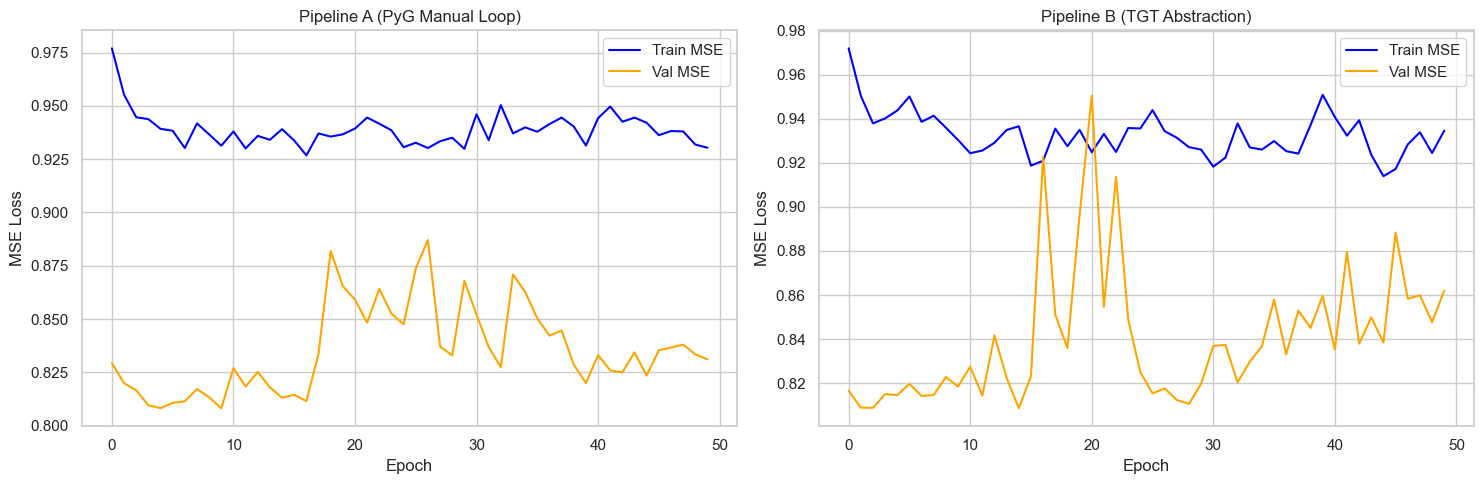

In [ ]:
def train_pipeline(
    model: nn.Module, 
    train_data: typing.Iterable, 
    val_data: typing.Iterable, 
    is_tgt: bool = False,
    epochs: int = 50,
    lr: float = 0.01
) -> Tuple[List[float], List[float]]:
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        h = None
        epoch_loss = 0.0
        steps = 0
        
        optimizer.zero_grad()
        
        for snap in train_data:
            edge_weight = snap.edge_weight if is_tgt else snap.edge_attr
            
            y_pred, h = model(snap.x, snap.edge_index, edge_weight, h)
            
            loss = criterion(y_pred, snap.y)
            epoch_loss += loss.item()
            loss.backward()
            
            h = h.detach()
            steps += 1
            
            optimizer.step()
            optimizer.zero_grad()
            
        train_losses.append(epoch_loss / steps)
        
        model.eval()
        h_val = None
        val_loss = 0.0
        val_steps = 0
        with torch.no_grad():
            for snap in val_data:
                edge_weight = snap.edge_weight if is_tgt else snap.edge_attr
                y_pred, h_val = model(snap.x, snap.edge_index, edge_weight, h_val)
                val_loss += criterion(y_pred, snap.y).item()
                val_steps += 1
                
        val_losses.append(val_loss / val_steps)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:02d} | Train MSE: {train_losses[-1]:.4f} | Val MSE: {val_losses[-1]:.4f}")
            
    return train_losses, val_losses

print("=== Обучение Варианта A (torch_geometric) ===")
model_pyg = BasicTGCN(in_channels=4, hidden_channels=16, out_channels=1)
train_loss_pyg, val_loss_pyg = train_pipeline(model_pyg, train_dataset_pyg, val_dataset_pyg, is_tgt=False)

print("\n=== Обучение Варианта B (torch_geometric_temporal) ===")
train_dataset_tgt_list = list(train_dataset_tgt)
val_dataset_tgt_list = list(val_dataset_tgt)

model_tgt = BasicTGCN(in_channels=4, hidden_channels=16, out_channels=1)
train_loss_tgt, val_loss_tgt = train_pipeline(model_tgt, train_dataset_tgt_list, val_dataset_tgt_list, is_tgt=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(train_loss_pyg, label='Train MSE', color='blue')
axes[0].plot(val_loss_pyg, label='Val MSE', color='orange')
axes[0].set_title('Pipeline A (PyG Manual Loop)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(train_loss_tgt, label='Train MSE', color='blue')
axes[1].plot(val_loss_tgt, label='Val MSE', color='orange')
axes[1].set_title('Pipeline B (TGT Abstraction)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

<p class="task" id="5"></p>

5. Оцените модели на тестовом отрезке времени.

Сделайте для обоих вариантов:
* итоговую метрику на test;
* график предсказания vs истинного значения для нескольких узлов;
* анализ ошибок по времени (на каких шагах ошибка максимальна).

Кратко объясните различия между вариантами A и B: удобство кода, воспроизводимость, вычислительные издержки.

- [ ] Проверено на семинаре


=== Результаты на Test ===
PyG (Manual) MSE: 0.9978
TGT (Abstract) MSE: 1.0572


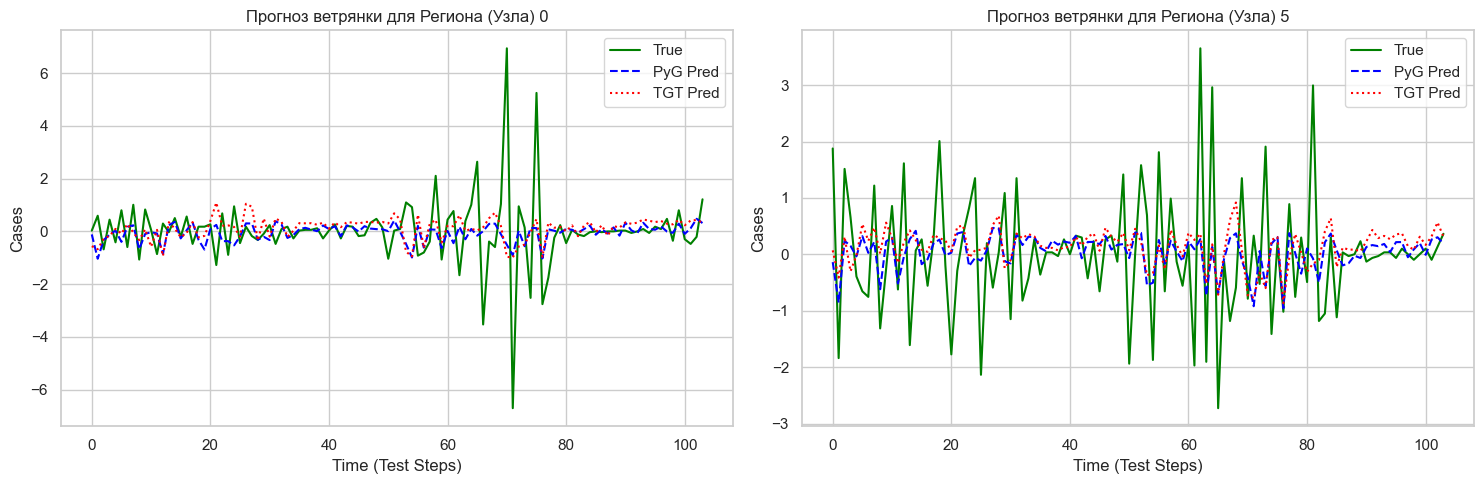

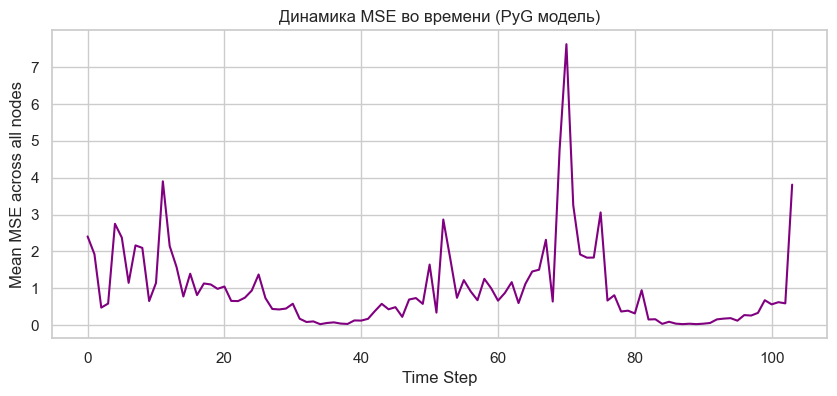

In [ ]:
def evaluate_model(model: nn.Module, test_data: typing.Iterable, is_tgt: bool):
    model.eval()
    criterion = nn.MSELoss(reduction='none')
    
    h = None
    all_preds = []
    all_targets = []
    all_errors = []
    
    with torch.no_grad():
        for snap in test_data:
            edge_weight = snap.edge_weight if is_tgt else snap.edge_attr
            y_pred, h = model(snap.x, snap.edge_index, edge_weight, h)
            
            all_preds.append(y_pred.numpy())
            all_targets.append(snap.y.numpy())
            
            err = criterion(y_pred, snap.y).numpy()
            all_errors.append(err)
            
    all_preds = np.stack(all_preds)
    all_targets = np.stack(all_targets)
    all_errors = np.stack(all_errors)
    
    mean_mse = all_errors.mean()
    return mean_mse, all_preds, all_targets, all_errors

test_dataset_tgt_list = list(test_dataset_tgt)

mse_pyg, preds_pyg, targets_pyg, errs_pyg = evaluate_model(model_pyg, test_dataset_pyg, is_tgt=False)
mse_tgt, preds_tgt, targets_tgt, errs_tgt = evaluate_model(model_tgt, test_dataset_tgt_list, is_tgt=True)

print(f"=== Результаты на Test ===")
print(f"PyG (Manual) MSE: {mse_pyg:.4f}")
print(f"TGT (Abstract) MSE: {mse_tgt:.4f}")

node_ids = [0, 5]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, node_idx in enumerate(node_ids):
    axes[i].plot(targets_pyg[:, node_idx], label='True', color='green')
    axes[i].plot(preds_pyg[:, node_idx], label='PyG Pred', linestyle='--', color='blue')
    axes[i].plot(preds_tgt[:, node_idx], label='TGT Pred', linestyle=':', color='red')
    axes[i].set_title(f'Прогноз ветрянки для Региона (Узла) {node_idx}')
    axes[i].set_xlabel('Time (Test Steps)')
    axes[i].set_ylabel('Cases')
    axes[i].legend()
plt.tight_layout()
plt.show()

mean_errs_over_time_pyg = errs_pyg.mean(axis=1) # [Time_Steps]
plt.figure(figsize=(10, 4))
plt.plot(mean_errs_over_time_pyg, color='purple')
plt.title('Динамика MSE во времени (PyG модель)')
plt.xlabel('Time Step')
plt.ylabel('Mean MSE across all nodes')
plt.show()

<p class="task" id="6"></p>

6. Финальное задание (повышенной сложности): `RGCN-GRU` для темпорального графа.

Постановка:
* расширьте базовый TGCN до `RGCN-GRU`: вместо обычной графовой свертки используйте реляционную (`RGCN`-стиль) + рекуррентную динамику `GRU`;
* определите схему `edge_type` для выбранного датасета (например, через дискретизацию весов/типов связей или через инженерный способ выделения 2-4 типов отношений);
* сравните `TGCN` vs `RGCN-GRU` на одинаковом train/val/test протоколе.

Что требуется в отчете:
* таблица: число параметров, время обучения, test-метрика;
* 1-2 графика динамики качества;
* вывод, когда усложнение до `RGCN-GRU` оправдано.

- [ ] Проверено на семинаре



=== Обучение RGCN-GRU ===

=== Сравнение метрик (Test MSE) ===
TGCN: 0.9978
RGCN-GRU: 0.8108


,Model,Params,Test MSE
0,TGCN,1841,0.997834
1,RGCN-GRU,1921,0.810774


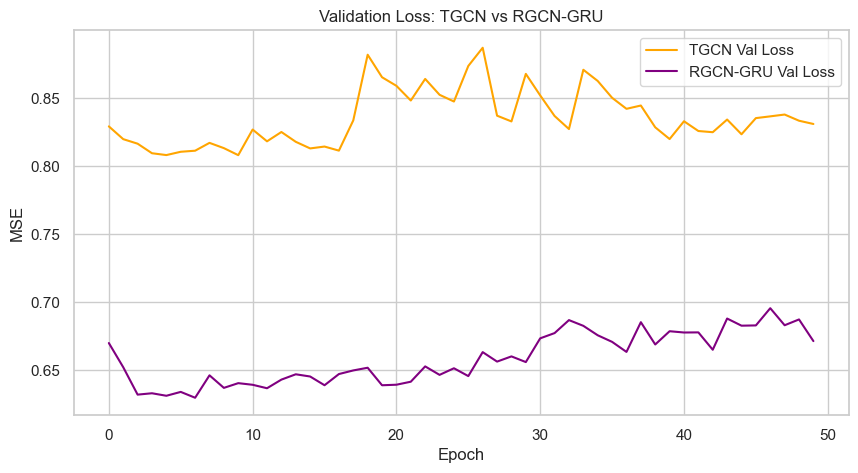

In [ ]:
class RGCN_GRU(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int, num_relations: int):
        super().__init__()
        self.rgcn = RGCNConv(in_channels, hidden_channels, num_relations=num_relations)
        self.gru = nn.GRUCell(hidden_channels, hidden_channels)
        self.linear = nn.Linear(hidden_channels, out_channels)

    def forward(self, x: Tensor, edge_index: Tensor, edge_type: Tensor, h_prev: typing.Optional[Tensor] = None) -> Tuple[Tensor, Tensor]:
        x_graph = self.rgcn(x, edge_index, edge_type)
        x_graph = F.relu(x_graph)
        
        if h_prev is None:
            h_prev = torch.zeros(x.size(0), self.gru.hidden_size, device=x.device)
            
        h_next = self.gru(x_graph, h_prev) # [Num_Nodes, Hidden_Channels]
        
        y_pred = self.linear(h_next)
        return y_pred.squeeze(-1), h_next

sample_edges = dataset_tgt_list = list(loader.get_dataset())
sample_weight = sample_edges[0].edge_attr

q33 = torch.quantile(sample_weight, 0.33)
q66 = torch.quantile(sample_weight, 0.66)
boundaries = torch.tensor([q33, q66])

def train_rgcn_pipeline(model, train_data, val_data, epochs=50, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        h, epoch_loss, steps = None, 0.0, 0
        optimizer.zero_grad()
        
        for snap in train_data:
            edge_type = torch.bucketize(snap.edge_attr, boundaries)
            
            y_pred, h = model(snap.x, snap.edge_index, edge_type, h)
            loss = criterion(y_pred, snap.y)
            epoch_loss += loss.item()
            loss.backward()
            
            h = h.detach()
            steps += 1
            optimizer.step()
            optimizer.zero_grad()
            
        train_losses.append(epoch_loss / steps)
        
        model.eval()
        h_val, val_loss, val_steps = None, 0.0, 0
        with torch.no_grad():
            for snap in val_data:
                edge_type = torch.bucketize(snap.edge_attr, boundaries)
                y_pred, h_val = model(snap.x, snap.edge_index, edge_type, h_val)
                val_loss += criterion(y_pred, snap.y).item()
                val_steps += 1
                
        val_losses.append(val_loss / val_steps)
    return train_losses, val_losses

model_rgcn = RGCN_GRU(in_channels=4, hidden_channels=16, out_channels=1, num_relations=3)
print("\n=== Обучение RGCN-GRU ===")
train_loss_rgcn, val_loss_rgcn = train_rgcn_pipeline(model_rgcn, train_dataset_pyg, val_dataset_pyg, epochs=50)

model_rgcn.eval()
criterion = nn.MSELoss()
test_mse_rgcn, h_test = 0.0, None
test_steps = 0
with torch.no_grad():
    for snap in test_dataset_pyg:
        edge_type = torch.bucketize(snap.edge_attr, boundaries)
        y_pred, h_test = model_rgcn(snap.x, snap.edge_index, edge_type, h_test)
        test_mse_rgcn += criterion(y_pred, snap.y).item()
        test_steps += 1
test_mse_rgcn /= test_steps

print(f"\n=== Сравнение метрик (Test MSE) ===")
print(f"TGCN: {mse_pyg:.4f}")
print(f"RGCN-GRU: {test_mse_rgcn:.4f}")

params_tgcn = sum(p.numel() for p in model_pyg.parameters() if p.requires_grad)
params_rgcn = sum(p.numel() for p in model_rgcn.parameters() if p.requires_grad)

import pandas as pd
df = pd.DataFrame({
    "Model": ["TGCN", "RGCN-GRU"],
    "Params": [params_tgcn, params_rgcn],
    "Test MSE": [mse_pyg, test_mse_rgcn]
})
display(df)

plt.figure(figsize=(10, 5))
plt.plot(val_loss_pyg, label='TGCN Val Loss', color='orange')
plt.plot(val_loss_rgcn, label='RGCN-GRU Val Loss', color='purple')
plt.title('Validation Loss: TGCN vs RGCN-GRU')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

## Мини-чеклист перед сдачей

- [ ] Использован один и тот же датасет из `torch_geometric_temporal` во всех заданиях.
- [ ] Реализованы оба варианта пайплайна: на `torch_geometric` и на `torch_geometric_temporal`.
- [ ] Финальное сравнение `TGCN` и `RGCN-GRU` выполнено на одинаковом протоколе оценки.
